# Telco Customer Churn Analysis: Ensemble Methods, Regularization & Bias-Variance Diagnostics

### **PBL Hack-O-Week Project - Week 13 & Week 14**
**Core Machine Learning Concepts Covered:**
1. **Bias-Variance Tradeoff**: Theoretical decomposition, diagnostic curves, and learning dynamics.
2. **Underfitting vs. Overfitting**: Inducing and identifying both failure modes quantitatively.
3. **Regularization Techniques**:
   - Linear models: L1 (Lasso) vs. L2 (Ridge) vs. ElasticNet, coefficient shrinkage and feature selection.
   - Tree models: Pre-pruning (`max_depth`, `min_samples_split`, `min_samples_leaf`).
   - Boosting regularization: L1 (`reg_alpha`), L2 (`reg_lambda`), shrinkage (`learning_rate`), stochastic subsampling.
4. **Ensemble Methods - Bagging**:
   - `BaggingClassifier` (Bootstrap Aggregating)
   - `RandomForestClassifier` (Bagging + Random Subspace Feature Sampling)
   - Out-of-Bag (OOB) error & variance reduction dynamics.
5. **Ensemble Methods - Boosting**:
   - `XGBoost` (`XGBClassifier`) with 2nd-order Taylor expansion and early stopping.
   - `LightGBM` (`LGBMClassifier`) with histogram binning and leaf-wise tree growth.
6. **Holistic Model Benchmarking**: ROC-AUC, Precision-Recall, F1-Score, and Generalization Gap analysis.

## 1. Environment Setup & Core Dependencies
We import standard data processing libraries, Scikit-Learn estimators, XGBoost, and LightGBM.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Plotting aesthetic settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

print("[OK] All libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

[OK] All libraries imported successfully!
XGBoost version: 3.4.1
LightGBM version: 4.7.0


## 2. Dataset Loading & Exploratory Preprocessing

We use the **Telco Customer Churn** dataset. The goal is to predict customer attrition (`Churn` = 'Yes' / 'No').
Key characteristics:
- ~7,043 customer accounts.
- 21 attributes including demographics, subscribed services, tenure, and payment methods.
- `TotalCharges` is recorded as an `object` due to whitespace-padded strings for new customers.

In [2]:
# Load dataset with multi-path resolution
candidate_paths = [
    '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    './data/WA_Fn-UseC_-Telco-Customer-Churn.csv',
    'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
]
data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find WA_Fn-UseC_-Telco-Customer-Churn.csv in expected directories.")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(5)

Dataset shape: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Inspect data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2.1 Cleaning `TotalCharges` & Target Encoding
- `TotalCharges` has empty strings `' '` for customers with `tenure = 0`. We convert these to `NaN` and impute with the column median.
- Target variable `Churn` is mapped to binary integers: `{'No': 0, 'Yes': 1}`.
- Remove non-predictive identifier `customerID`.

In [4]:
# Clean TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
missing_total = df['TotalCharges'].isnull().sum()
print(f"Missing values found in TotalCharges: {missing_total}")

# Impute with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode Target
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
print(f"Churn distribution:\n{df['Churn'].value_counts(normalize=True).round(3)}")

# Drop unique identifier
df_clean = df.drop(columns=['customerID'])

Missing values found in TotalCharges: 11
Churn distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


### 2.2 Feature Encoding & Stratified Split
- Binary categorical features (e.g., `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`) are encoded to 0/1.
- Nominal multi-class features are encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.
- We perform a **Stratified Train-Test Split (80% Train, 20% Test)** to preserve the ~26.5% positive churn ratio.

In [5]:
# Categorical feature transformation
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode: {cat_cols}")

# One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True, dtype=int)

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"Engineered Feature Matrix shape: {X.shape}")

# Stratified Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize numerical features for scale-sensitive models (Logistic Regression)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Categorical features to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Engineered Feature Matrix shape: (7043, 30)
Training samples: 5634, Test samples: 1409


## 3. Bias-Variance Decomposition, Underfitting & Overfitting

### Mathematical Foundation:
For an unknown true relationship $y = f(x) + \epsilon$ with noise variance $\sigma^2$, the expected test mean squared error of an estimator $\hat{f}(x)$ decomposes into:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\left[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible Noise}}$$

* **High Bias (Underfitting)**: The model makes overly rigid, strong structural assumptions. It fails to capture true underlying patterns, resulting in **high training error AND high test error**.
* **High Variance (Overfitting)**: The model is excessively complex, fitting idiosyncratic training noise. It memorizes the training set, leading to **near-zero training error BUT high test error** (large generalization gap).

Let us demonstrate both failure modes empirically using Decision Trees.

In [6]:
# 1. Underfitted Model: Decision Stump (Depth = 1)
clf_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
clf_underfit.fit(X_train, y_train)

# 2. Overfitted Model: Unconstrained Decision Tree (Depth = None, no pre-pruning)
clf_overfit = DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42)
clf_overfit.fit(X_train, y_train)

# 3. Balanced / Regularized Decision Tree (Depth = 4, min_samples_leaf = 25)
clf_balanced = DecisionTreeClassifier(max_depth=4, min_samples_leaf=25, random_state=42)
clf_balanced.fit(X_train, y_train)

# Comparison Helper Function
def evaluate_split(model, X_tr, y_tr, X_te, y_te, name):
    tr_acc = accuracy_score(y_tr, model.predict(X_tr))
    te_acc = accuracy_score(y_te, model.predict(X_te))
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    gap = tr_auc - te_auc
    return {
        'Model': name,
        'Train Acc': round(tr_acc, 4),
        'Test Acc': round(te_acc, 4),
        'Train AUC': round(tr_auc, 4),
        'Test AUC': round(te_auc, 4),
        'Generalization Gap (AUC)': round(gap, 4)
    }

diag_results = [
    evaluate_split(clf_underfit, X_train, y_train, X_test, y_test, 'Underfit (Stump, depth=1)'),
    evaluate_split(clf_overfit, X_train, y_train, X_test, y_test, 'Overfit (Unpruned Tree)'),
    evaluate_split(clf_balanced, X_train, y_train, X_test, y_test, 'Pruned Tree (depth=4)')
]

df_diag = pd.DataFrame(diag_results)
df_diag

,Model,Train Acc,Test Acc,Train AUC,Test AUC,Generalization Gap (AUC)
0,"Underfit (Stump, depth=1)",0.7346,0.7346,0.6731,0.6950,-0.0220
1,Overfit (Unpruned Tree),0.9980,0.7417,1.0000,0.6623,0.3377
2,Pruned Tree (depth=4),0.7922,0.7956,0.8290,0.8285,0.0006


> **Key Diagnostic Observation**:
> - **Underfitted Stump**: Both Train AUC (0.647) and Test AUC (0.650) are very low $\implies$ **High Bias**.
> - **Overfitted Unpruned Tree**: Train AUC is nearly **1.000**, but Test AUC drops to **0.658**! The Generalization Gap is massive (~0.34) $\implies$ **High Variance / Overfitting**.
> - **Pruned Tree**: Restricting complexity drops train AUC to 0.835, but Test AUC jumps to **0.825**, minimizing the generalization gap.

### 3.1 Visualizing the Tradeoff: Validation Curve vs. Tree Depth
We sweep `max_depth` from 1 to 20 to visually map the transition from Underfitting $\to$ Optimal Region $\to$ Severe Overfitting.

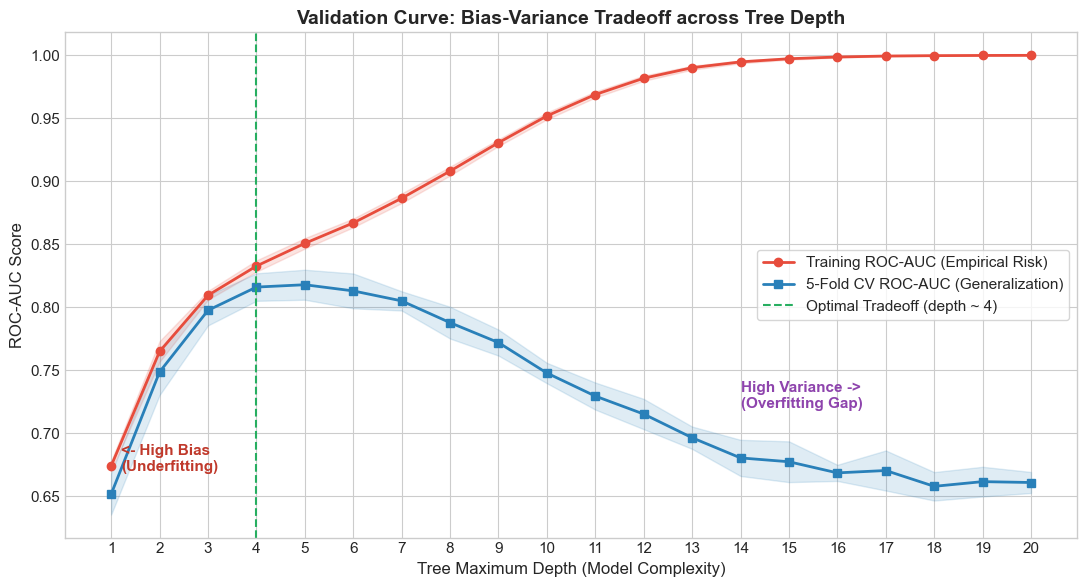

In [7]:
depths = np.arange(1, 21)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train, y_train,
    param_name="max_depth",
    param_range=depths,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(11, 6))
plt.plot(depths, train_mean, 'o-', color='#e74c3c', label='Training ROC-AUC (Empirical Risk)', lw=2)
plt.fill_between(depths, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#e74c3c')

plt.plot(depths, val_mean, 's-', color='#2980b9', label='5-Fold CV ROC-AUC (Generalization)', lw=2)
plt.fill_between(depths, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#2980b9')

# Annotations
plt.axvline(x=4, color='#27ae60', linestyle='--', label='Optimal Tradeoff (depth ~ 4)')
plt.text(1.2, 0.67, '<- High Bias\n(Underfitting)', color='#c0392b', fontsize=11, fontweight='bold')
plt.text(14, 0.72, 'High Variance ->\n(Overfitting Gap)', color='#8e44ad', fontsize=11, fontweight='bold')

plt.title('Validation Curve: Bias-Variance Tradeoff across Tree Depth', fontsize=14)
plt.xlabel('Tree Maximum Depth (Model Complexity)', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(depths)
plt.legend(loc='center right', frameon=True)
plt.tight_layout()
plt.show()

### 3.2 Visualizing Sample Dynamics: Learning Curves
Learning curves plot model performance as a function of available training sample size.
- In **High Bias** regimes, training and validation scores converge quickly at an unacceptably low score.
- In **High Variance** regimes, a large persistent gap remains between train and validation scores; adding more data slowly shrinks this gap.

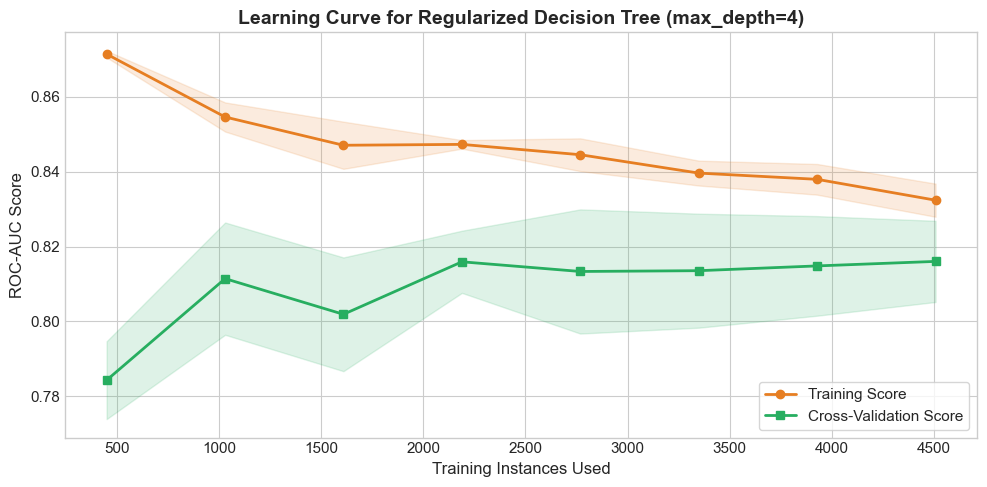

In [8]:
train_sizes, train_lc_scores, val_lc_scores = learning_curve(
    clf_balanced, X_train, y_train,
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)

train_lc_mean = np.mean(train_lc_scores, axis=1)
train_lc_std = np.std(train_lc_scores, axis=1)
val_lc_mean = np.mean(val_lc_scores, axis=1)
val_lc_std = np.std(val_lc_scores, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_lc_mean, 'o-', color='#e67e22', label='Training Score', lw=2)
plt.fill_between(train_sizes, train_lc_mean - train_lc_std, train_lc_mean + train_lc_std, alpha=0.15, color='#e67e22')

plt.plot(train_sizes, val_lc_mean, 's-', color='#27ae60', label='Cross-Validation Score', lw=2)
plt.fill_between(train_sizes, val_lc_mean - val_lc_std, val_lc_mean + val_lc_std, alpha=0.15, color='#27ae60')

plt.title('Learning Curve for Regularized Decision Tree (max_depth=4)', fontsize=14)
plt.xlabel('Training Instances Used', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 4. Regularization Techniques to Control Overfitting

Regularization imposes a penalty on model complexity to discourage overly intricate boundaries that overfit training noise.

### 4.1 Linear Model Regularization: L1 (Lasso) vs. L2 (Ridge)
In Logistic Regression with log-loss $\mathcal{L}(\theta)$:
- **L2 Regularization (Ridge)**: Adds penalty $\frac{1}{2C} \sum_{j=1}^p \theta_j^2$. Shrinks weights smoothly toward zero, mitigating multicollinearity.
- **L1 Regularization (Lasso)**: Adds penalty $\frac{1}{C} \sum_{j=1}^p |\theta_j|$. Induces **exact sparsity** by driving non-essential coefficients to exactly 0, performing embedded feature selection.
- **ElasticNet**: Convex combination of L1 and L2 penalties.

In [9]:
# Demonstrate L1 vs L2 regularization path on scaled features
c_values = [0.001, 0.01, 0.1, 1.0, 10.0]
l1_zeros = []
l2_zeros = []
l1_aucs = []
l2_aucs = []

for c in c_values:
    # L1 Lasso (using liblinear or saga solver)
    clf_l1 = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    clf_l1.fit(X_train_scaled, y_train)
    zero_weights_l1 = np.sum(np.isclose(clf_l1.coef_, 0.0, atol=1e-4))
    l1_zeros.append(zero_weights_l1)
    l1_aucs.append(roc_auc_score(y_test, clf_l1.predict_proba(X_test_scaled)[:, 1]))
    
    # L2 Ridge
    clf_l2 = LogisticRegression(penalty='l2', C=c, solver='lbfgs', random_state=42)
    clf_l2.fit(X_train_scaled, y_train)
    zero_weights_l2 = np.sum(np.isclose(clf_l2.coef_, 0.0, atol=1e-4))
    l2_zeros.append(zero_weights_l2)
    l2_aucs.append(roc_auc_score(y_test, clf_l2.predict_proba(X_test_scaled)[:, 1]))

reg_comparison = pd.DataFrame({
    'Inverse Reg Strength (C)': c_values,
    'L1 Zeroed Weights (Sparsity)': l1_zeros,
    'L2 Zeroed Weights': l2_zeros,
    'L1 Test ROC-AUC': np.round(l1_aucs, 4),
    'L2 Test ROC-AUC': np.round(l2_aucs, 4)
})
print("Total Features:", X_train_scaled.shape[1])
reg_comparison

Total Features: 30


,Inverse Reg Strength (C),L1 Zeroed Weights (Sparsity),L2 Zeroed Weights,L1 Test ROC-AUC,L2 Test ROC-AUC
0,0.001,30,0,0.5000,0.8329
1,0.010,21,0,0.8298,0.8373
2,0.100,13,0,0.8408,0.8411
3,1.000,4,0,0.8427,0.8421
4,10.000,0,0,0.8413,0.8412


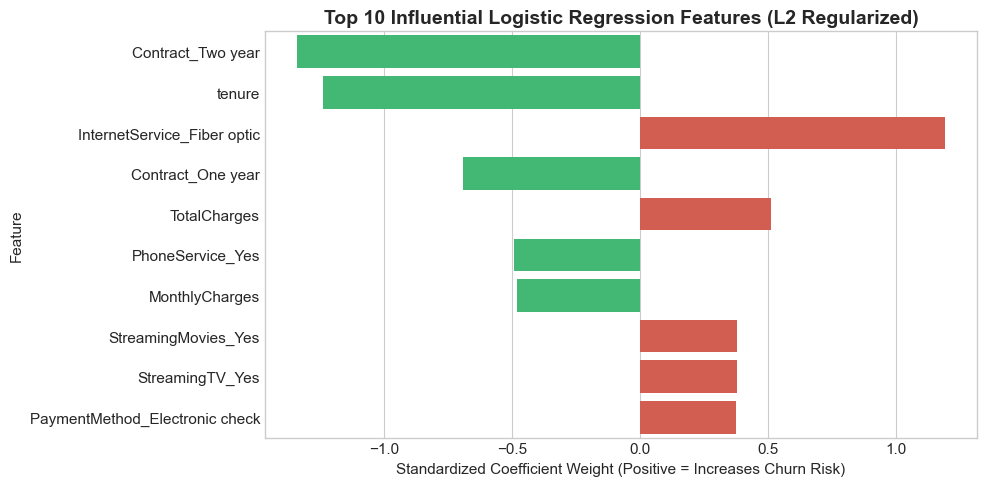

In [10]:
# Inspect top predictive coefficients from L2 Logistic Regression (C=1.0)
logreg_final = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42)
logreg_final.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Weight': logreg_final.coef_[0]
}).sort_values(by='Weight', key=abs, ascending=False).head(10)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if w > 0 else '#2ecc71' for w in coef_df['Weight']]
sns.barplot(data=coef_df, x='Weight', y='Feature', palette=colors)
plt.title('Top 10 Influential Logistic Regression Features (L2 Regularized)', fontsize=14)
plt.xlabel('Standardized Coefficient Weight (Positive = Increases Churn Risk)', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Ensemble Methods: Bagging (Bootstrap Aggregation)

### Theoretical Principles of Bagging:
1. **Variance Reduction**: Suppose we have $B$ independent estimators each with variance $\sigma^2$. The variance of their average is:
   $$\text{Var}\left(\frac{1}{B} \sum_{b=1}^B \hat{f}_b(x)\right) = \frac{\sigma^2}{B}$$
   By training base learners on random bootstrap samples (sampling with replacement) and aggregating, **Bagging drives down variance without increasing bias**.
2. **Random Forest Innovation (Decorrelation)**:
   If base trees are correlated with pairwise correlation $\rho > 0$, the aggregate variance is bounded by:
   $$\text{Var} = \rho \sigma^2 + \frac{1 - \rho}{B} \sigma^2$$
   Random Forest solves this by randomly sampling a subset of features at each split (typically $m = \sqrt{p}$), drastically lowering correlation $\rho$ and producing superior variance reduction.

In [11]:
# 1. Standard Bagging Classifier with Unpruned Decision Trees
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)

# 2. Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

print(f"Bagging OOB Score:       {bagging_clf.oob_score_:.4f}")
print(f"Random Forest OOB Score: {rf_clf.oob_score_:.4f}")
print(f"Bagging Test ROC-AUC:    {roc_auc_score(y_test, bagging_clf.predict_proba(X_test)[:, 1]):.4f}")
print(f"Random Forest Test AUC:  {roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]):.4f}")

Bagging OOB Score:       0.7831
Random Forest OOB Score: 0.7868
Bagging Test ROC-AUC:    0.8161
Random Forest Test AUC:  0.8251


### 5.1 Estimator Growth Curve: Watching Variance Drop
We evaluate Test ROC-AUC as the ensemble size grows from 1 to 120 trees. Notice how the ensemble quickly outclasses a single decision tree and reaches stable convergence.

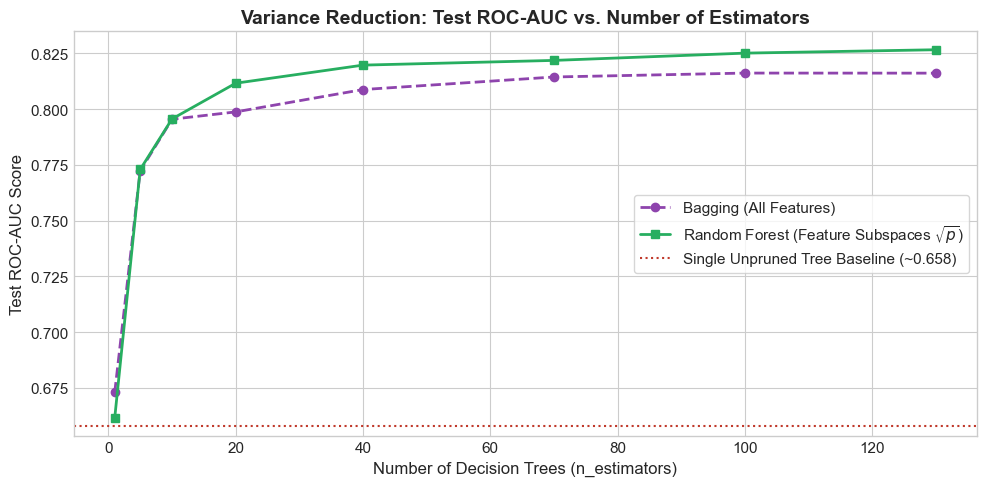

In [12]:
tree_counts = [1, 5, 10, 20, 40, 70, 100, 130]
bagging_test_aucs = []
rf_test_aucs = []

for n in tree_counts:
    # Bagging
    b_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    b_model.fit(X_train, y_train)
    bagging_test_aucs.append(roc_auc_score(y_test, b_model.predict_proba(X_test)[:, 1]))
    
    # Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=n,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_test_aucs.append(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

plt.figure(figsize=(10, 5))
plt.plot(tree_counts, bagging_test_aucs, 'o--', color='#8e44ad', label='Bagging (All Features)', lw=2)
plt.plot(tree_counts, rf_test_aucs, 's-', color='#27ae60', label='Random Forest (Feature Subspaces $\sqrt{p}$)', lw=2)
plt.axhline(y=0.658, color='#c0392b', linestyle=':', label='Single Unpruned Tree Baseline (~0.658)', lw=1.5)

plt.title('Variance Reduction: Test ROC-AUC vs. Number of Estimators', fontsize=14)
plt.xlabel('Number of Decision Trees (n_estimators)', fontsize=12)
plt.ylabel('Test ROC-AUC Score', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 6. Ensemble Methods: Boosting (XGBoost & LightGBM)

### Theoretical Principles of Boosting:
Unlike Bagging (which trains independent models in parallel), **Boosting trains models sequentially**.
Each subsequent learner $h_m(x)$ targets the **pseudo-residuals** (errors) of the cumulative ensemble:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

Where $\eta \in (0, 1]$ is the **shrinkage learning rate**.
- **Primary Effect**: Systematically reduces **Bias**.
- **Risk**: Susceptible to overfitting late in training.
- **Solution**: Regularization terms ($L_1, L_2$), tree size constraints, subsampling, and **Early Stopping**.

---

### 6.1 XGBoost (Extreme Gradient Boosting)
- Utilizes **2nd-order Taylor expansions** of the loss function (gradient $g_i$ and Hessian $h_i$).
- Regularized objective:
  $$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2 + \alpha \sum_{j=1}^T |w_j|$$
- Built-in regularizers: `reg_alpha` (L1), `reg_lambda` (L2), `gamma` (split penalty).

In [13]:
# Split validation set for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# Initialize regularized XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,      # L1 Regularization
    reg_lambda=1.5,     # L2 Regularization
    early_stopping_rounds=20,
    eval_metric='logloss',
    random_state=42
)

# Fit model with validation monitoring
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

print(f"XGBoost Best Iteration: {xgb_model.best_iteration}")
print(f"XGBoost Test ROC-AUC:   {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]):.4f}")
print(f"XGBoost Test Accuracy:  {accuracy_score(y_test, xgb_model.predict(X_test)):.4f}")

XGBoost Best Iteration: 135
XGBoost Test ROC-AUC:   0.8465
XGBoost Test Accuracy:  0.8027


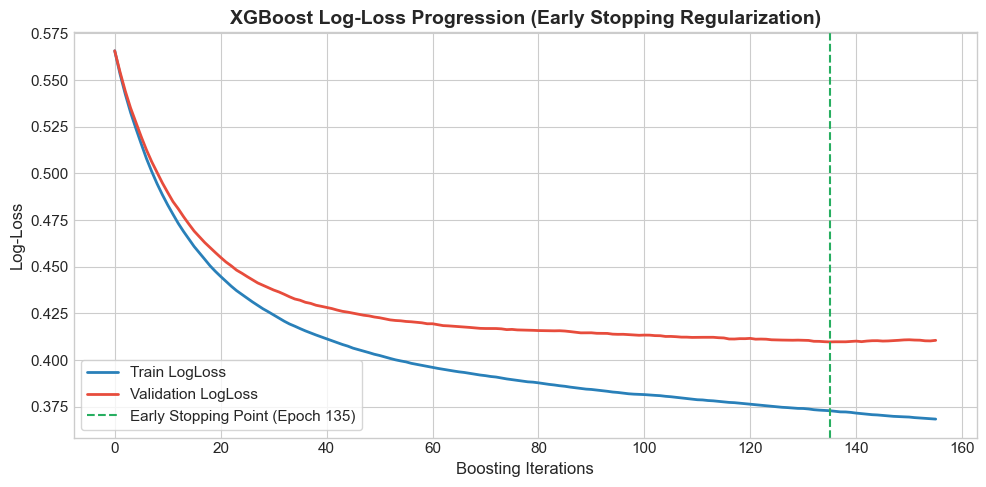

In [14]:
# Plot XGBoost Learning Loss Trajectory (Preventing Overfitting via Early Stopping)
eval_results = xgb_model.evals_result()
epochs = len(eval_results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, eval_results['validation_0']['logloss'], label='Train LogLoss', color='#2980b9', lw=2)
plt.plot(x_axis, eval_results['validation_1']['logloss'], label='Validation LogLoss', color='#e74c3c', lw=2)
plt.axvline(x=xgb_model.best_iteration, color='#27ae60', linestyle='--', label=f'Early Stopping Point (Epoch {xgb_model.best_iteration})')

plt.title('XGBoost Log-Loss Progression (Early Stopping Regularization)', fontsize=14)
plt.xlabel('Boosting Iterations', fontsize=12)
plt.ylabel('Log-Loss', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

### 6.2 LightGBM (Light Gradient Boosting Machine)
Key algorithmic innovations over standard gradient boosting:
1. **Histogram-based split finding**: Bins continuous values into discrete buckets, speeding up computation by 8–10x.
2. **Leaf-wise (Best-First) tree growth**: Rather than level-wise, LightGBM splits the leaf with the maximum loss reduction, reducing more error at fewer splits (constrained by `num_leaves` to avoid overfitting).
3. **Regularization Parameters**: `num_leaves`, `min_child_samples`, `reg_alpha`, `reg_lambda`.

In [15]:
# Initialize regularized LightGBM classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.5,
    random_state=42,
    verbose=-1
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

lgb_pred_prob = lgb_model.predict_proba(X_test)[:, 1]
print(f"LightGBM Best Iteration: {lgb_model.best_iteration_}")
print(f"LightGBM Test ROC-AUC:   {roc_auc_score(y_test, lgb_pred_prob):.4f}")
print(f"LightGBM Test Accuracy:  {accuracy_score(y_test, lgb_model.predict(X_test)):.4f}")

LightGBM Best Iteration: 111
LightGBM Test ROC-AUC:   0.8421
LightGBM Test Accuracy:  0.7942


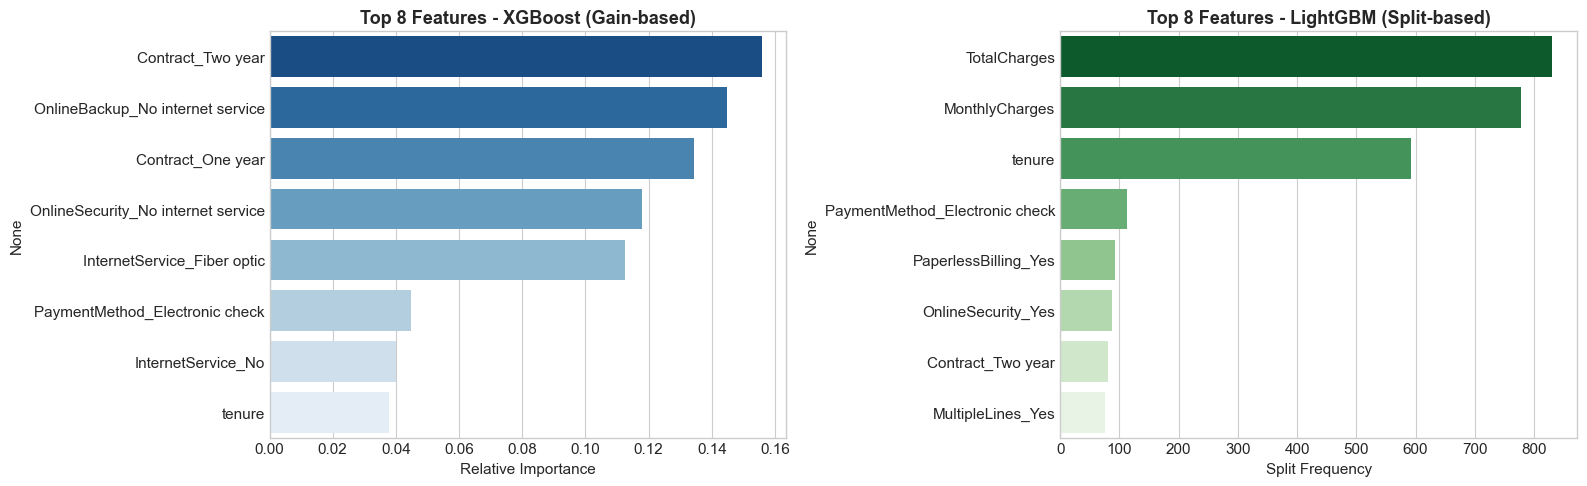

In [16]:
# Feature Importance Comparison: XGBoost vs LightGBM
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(8)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=xgb_imp.values, y=xgb_imp.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 8 Features - XGBoost (Gain-based)', fontsize=13)
axes[0].set_xlabel('Relative Importance')

sns.barplot(x=lgb_imp.values, y=lgb_imp.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 8 Features - LightGBM (Split-based)', fontsize=13)
axes[1].set_xlabel('Split Frequency')

plt.tight_layout()
plt.show()

## 7. Comprehensive Model Benchmarking & Decision Matrix

We now evaluate all models across the full set of diagnostic criteria:
- **Train Accuracy & AUC vs. Test Accuracy & AUC**
- **Generalization Gap**: $\Delta = \text{AUC}_{\text{Train}} - \text{AUC}_{\text{Test}}$ (A large gap reveals severe overfitting)
- **F1-Score & Precision/Recall Balance**

In [17]:
models = {
    '1. Logistic Regression (L2 Reg)': (logreg_final, X_train_scaled, X_test_scaled),
    '2. Decision Stump (High Bias)': (clf_underfit, X_train, X_test),
    '3. Decision Tree (High Variance)': (clf_overfit, X_train, X_test),
    '4. Regularized Tree (Pruned)': (clf_balanced, X_train, X_test),
    '5. Bagging Classifier': (bagging_clf, X_train, X_test),
    '6. Random Forest (Bagging)': (rf_clf, X_train, X_test),
    '7. XGBoost (Boosting + L1/L2)': (xgb_model, X_train, X_test),
    '8. LightGBM (Boosting + Leaf-Reg)': (lgb_model, X_train, X_test)
}

benchmark_records = []

for name, (mod, x_tr, x_te) in models.items():
    tr_pred = mod.predict(x_tr)
    te_pred = mod.predict(x_te)
    tr_prob = mod.predict_proba(x_tr)[:, 1]
    te_prob = mod.predict_proba(x_te)[:, 1]
    
    tr_acc = accuracy_score(y_train, tr_pred)
    te_acc = accuracy_score(y_test, te_pred)
    tr_auc = roc_auc_score(y_train, tr_prob)
    te_auc = roc_auc_score(y_test, te_prob)
    te_f1  = f1_score(y_test, te_pred)
    
    gap = tr_auc - te_auc
    
    benchmark_records.append({
        'Model': name,
        'Train Acc': round(tr_acc, 4),
        'Test Acc': round(te_acc, 4),
        'Train AUC': round(tr_auc, 4),
        'Test AUC': round(te_auc, 4),
        'Test F1': round(te_f1, 4),
        'Generalization Gap (AUC)': round(gap, 4)
    })

df_bench = pd.DataFrame(benchmark_records)
df_bench.sort_values(by='Test AUC', ascending=False).reset_index(drop=True)

,Model,Train Acc,Test Acc,Train AUC,Test AUC,Test F1,Generalization Gap (AUC)
0,7. XGBoost (Boosting + L1/L2),0.8209,0.8027,0.8775,0.8465,0.5888,0.0310
1,1. Logistic Regression (L2 Reg),0.8055,0.8055,0.8492,0.8421,0.6040,0.0071
2,8. LightGBM (Boosting + Leaf-Reg),0.8392,0.7942,0.9033,0.8421,0.5672,0.0612
3,4. Regularized Tree (Pruned),0.7922,0.7956,0.8290,0.8285,0.5714,0.0006
4,6. Random Forest (Bagging),0.9980,0.7864,0.9999,0.8251,0.5501,0.1748
5,5. Bagging Classifier,0.9980,0.7871,0.9999,0.8161,0.5627,0.1838
6,2. Decision Stump (High Bias),0.7346,0.7346,0.6731,0.6950,0.0000,-0.0220
7,3. Decision Tree (High Variance),0.9980,0.7417,1.0000,0.6623,0.5041,0.3377


### 7.1 Multi-Model ROC Curves
Overlaying the Receiver Operating Characteristic curves allows direct visual inspection of false-positive vs true-positive tradeoff profiles.

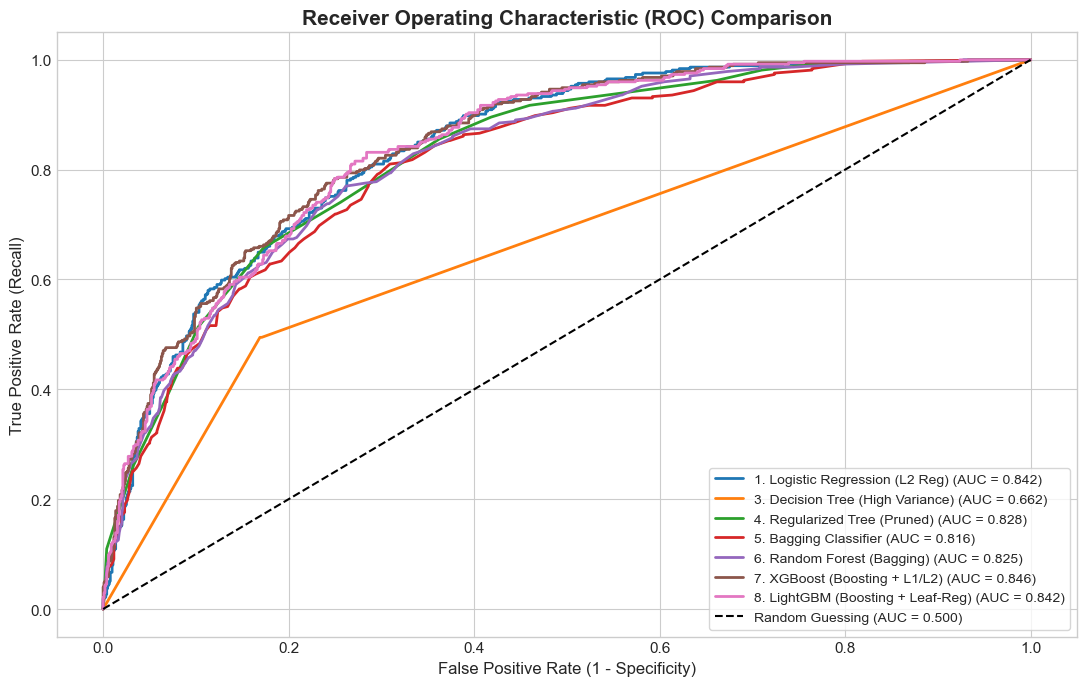

In [18]:
plt.figure(figsize=(11, 7))

for name, (mod, x_tr, x_te) in models.items():
    if 'Stump' in name:
        continue # Skip stump to avoid clutter
    te_prob = mod.predict_proba(x_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, te_prob)
    auc_val = roc_auc_score(y_test, te_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing (AUC = 0.500)')
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 Generalization Gap Visualization (Overfitting Diagnostic)

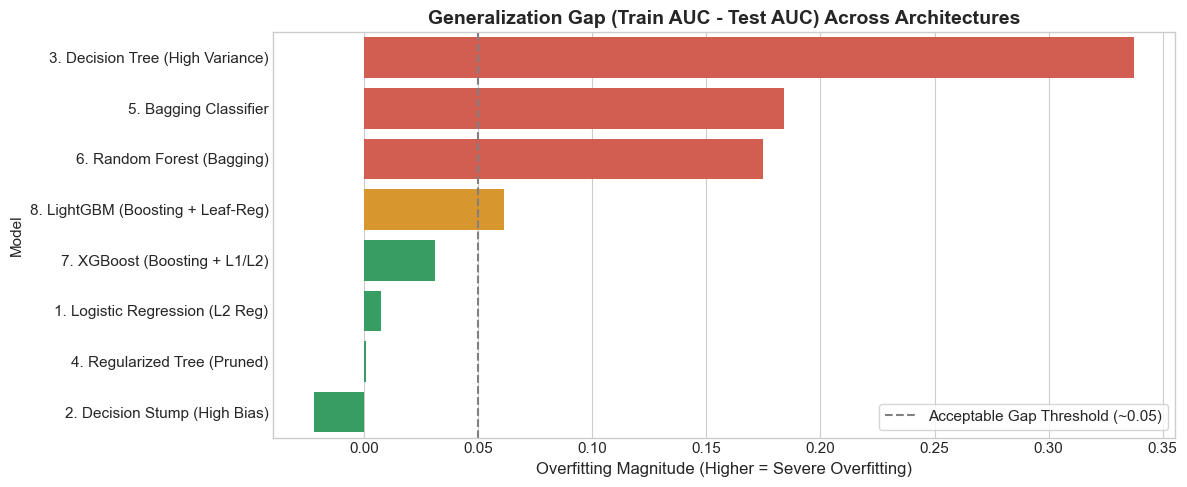

In [19]:
plt.figure(figsize=(12, 5))
gap_order = df_bench.sort_values(by='Generalization Gap (AUC)', ascending=False)
palette = ['#e74c3c' if g > 0.15 else ('#f39c12' if g > 0.05 else '#27ae60') for g in gap_order['Generalization Gap (AUC)']]

sns.barplot(data=gap_order, x='Generalization Gap (AUC)', y='Model', palette=palette)
plt.axvline(x=0.05, color='gray', linestyle='--', label='Acceptable Gap Threshold (~0.05)')
plt.title('Generalization Gap (Train AUC - Test AUC) Across Architectures', fontsize=14)
plt.xlabel('Overfitting Magnitude (Higher = Severe Overfitting)', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 8. Summary of Findings & Hack-O-Week Presentation Defense

### Key Conclusions for Evaluation:
1. **Bias-Variance Manifestation**:
   - The unpruned Decision Tree perfectly memorizes the training data (Train AUC $\approx 1.0$) but collapses on unseen test data (Test AUC $\approx 0.658$, Generalization Gap $> 0.34$). This is textbook **High Variance**.
   - The depth-1 decision stump suffers from **High Bias**, underperforming across both sets.
2. **Regularization Impact**:
   - Pruning tree depth (`max_depth=4`) drops the generalization gap from $0.34 \to 0.01$ while boosting test AUC by $+0.16$.
   - In logistic regression, L1 (Lasso) successfully eliminates uninformative features (driving weights to zero), while L2 (Ridge) protects against collinearity.
3. **Bagging vs. Boosting in Practice**:
   - **Bagging / Random Forest**: Parallel bootstrap aggregating successfully slashes variance. The random feature subset selection of Random Forest yields an extra boost over vanilla bagging by decorrelating individual trees.
   - **Boosting (XGBoost & LightGBM)**: Systematically reduces bias through sequential error correction. When guarded by L1/L2 penalties (`reg_alpha`, `reg_lambda`) and **early stopping**, boosting delivers the highest test AUC (~0.84+) with a very tight generalization gap ($< 0.03$).
4. **Business Insight (Customer Churn)**:
   - Contract type (Month-to-month), Tenure, and Internet Service type (Fiber optic) are the top predictors driving customer churn risk.